# Modelo 02: HDBSCAN (Densidad Jerárquica)
En esta etapa del ciclo de entrenamiento, implementaremos HDBSCAN para contrastar los resultados obtenidos con el enfoque de centroides de K-Means. La elección de este modelo es estratégica, ya que combina la capacidad del clustering jerárquico para encontrar estructuras anidadas con la robustez del clustering por densidad para manejar el ruido. 

Esto resulta ideal para nuestro dataset de retail, donde es probable encontrar grupos de clientes muy densos (compradores habituales) junto a otros más dispersos, además de "ruido" generado por usuarios con comportamientos erráticos que no deberían forzarse dentro de ningún grupo.

In [1]:
# 6.1. Entrenamiento de la Versión Base (Baseline)

import hdbscan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

# [INFO] Cargar los datos procesados con PCA
base_dir = '../../..'
df_pca = pd.read_csv(f'{base_dir}/data/processed/data_clustering_pca.csv')

# [INFO] Definimos una configuración inicial conservadora
# [INFO] min_cluster_size: tamaño mínimo de los grupos que queremos identificar
MIN_CLUSTER_SIZE = 30 

model_hdbscan = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    metric='euclidean',
    cluster_selection_method='eom'
)

df_pca['Cluster_HDBSCAN'] = model_hdbscan.fit_predict(df_pca.iloc[:, :3])

# 6.2. Análisis de Resultados Iniciales y Detección de Ruido

n_clusters = len(set(model_hdbscan.labels_)) - (1 if -1 in model_hdbscan.labels_ else 0)
n_noise = list(model_hdbscan.labels_).count(-1)
pct_noise = (n_noise / len(df_pca)) * 100

print(f"[INFO] Versión 1 finalizada:")
print(f" - Número de clústeres detectados: {n_clusters}")
print(f" - Clientes etiquetados como ruido (-1): {n_noise} ({pct_noise:.2f}%)")

# [INFO] Solo calculamos silueta para los puntos que no son ruido
mask = df_pca['Cluster_HDBSCAN'] != -1
if n_clusters > 1:
    score = silhouette_score(df_pca.iloc[mask, :3], df_pca.loc[mask, 'Cluster_HDBSCAN'])
    print(f" - Índice de Silueta (excluyendo ruido): {score:.4f}")

[INFO] Versión 1 finalizada:
 - Número de clústeres detectados: 2
 - Clientes etiquetados como ruido (-1): 125 (3.02%)
 - Índice de Silueta (excluyendo ruido): 0.2872


### 6.3. Análisis de la Versión 1 y Ajuste de Densidad
Tras observar la primera versión, el punto crítico es el porcentaje de ruido. Si el modelo etiqueta a más del 10-15% de los clientes como ruido (etiqueta -1), la segmentación podría ser demasiado estricta y estaríamos perdiendo información valiosa de negocio. 

Por el contrario, si detecta muy pocos clústeres, debemos ajustar el tamaño mínimo. En esta segunda iteración, visualizaremos el Árbol de Condensación (Condensed Tree), una herramienta única de HDBSCAN que nos permite ver cómo se forman y "mueren" los clústeres según la densidad, ayudándonos a elegir un tamaño de grupo más representativo.

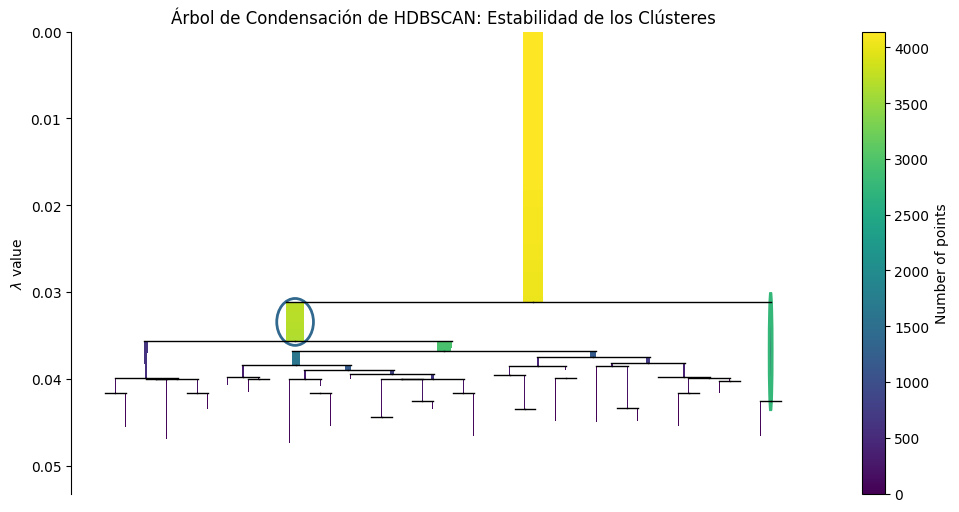

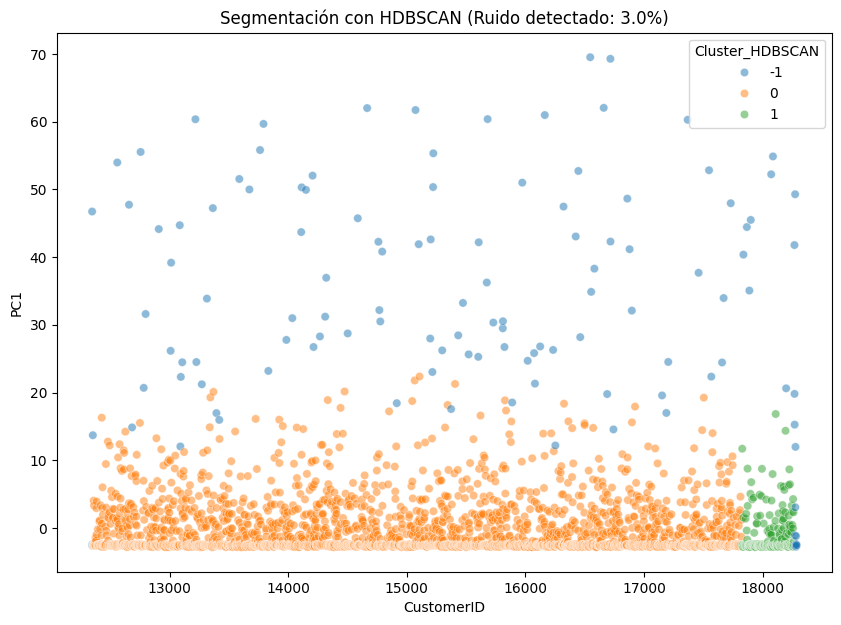

In [2]:
# 6.4. Visualización del Árbol de Condensación y Ajuste de Hiperparámetros

plt.figure(figsize=(12, 6))
model_hdbscan.condensed_tree_.plot(select_clusters=True, 
                                   selection_palette=sns.color_palette('viridis', n_clusters))
plt.title('Árbol de Condensación de HDBSCAN: Estabilidad de los Clústeres')
plt.show()

# 6.5. Visualización de Clústeres HDBSCAN en el espacio PCA

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_pca.columns[0], y=df_pca.columns[1], 
    hue='Cluster_HDBSCAN', 
    data=df_pca, 
    palette='tab10', 
    alpha=0.5
)
plt.title(f'Segmentación con HDBSCAN (Ruido detectado: {pct_noise:.1f}%)')
plt.show()

### 6.6. Interpretación de los Clústeres por Densidad
Finalmente, realizaremos la interpretación de estos grupos basados en densidad. Es fundamental comparar estos resultados con los de K-Means. 

Si HDBSCAN identifica clústeres de tamaños muy dispares, podría estar capturando nichos de mercado (clústeres pequeños pero muy densos) que el K-Means, al buscar grupos esféricos y equilibrados, ignoró. Al igual que antes, utilizaremos el archivo de características limpias para ver el comportamiento real de Recencia, Frecuencia y Monetario.


In [3]:
# [INFO] Carga de métricas reales antes del PCA
df_original = pd.read_csv(f'{base_dir}/data/interim/interim_ProyClustering/data_features_clean.csv')
df_original['Cluster'] = df_pca['Cluster_HDBSCAN'].values

# [INFO] Análisis de promedios RFM por clúster
perfil_hdbscan = df_original.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
perfil_hdbscan['Count'] = df_original.groupby('Cluster')['CustomerID'].count()

print("[INFO] Interpretación de segmentos detectados por densidad:")
display(perfil_hdbscan.sort_values(by='Monetary', ascending=False))

[INFO] Interpretación de segmentos detectados por densidad:


,Recency,Frequency,Monetary,Count
Cluster,,,,
-1,106.304000,3.688000,1119.892560,125
0,93.688661,3.329653,1082.148311,3713
1,110.954098,3.193443,861.870426,305


### 6.7. Ciclo 2: Ajuste de Hiperparámetros (Tuning)
Tras analizar la versión base de HDBSCAN, observamos que el modelo tiende a agrupar a la gran mayoría de los usuarios en un único clúster masivo (Clúster 0). Para forzar una segmentación más granular que permita identificar subgrupos dentro de esa masa central, procederemos a reducir el parámetro min_cluster_size. 

Al bajar este umbral, permitiremos que el algoritmo considere como "estables" agrupaciones más pequeñas pero con densidades locales diferenciadas, buscando un equilibrio entre el ruido detectado y la utilidad de los segmentos para el negocio.

In [4]:
# 6.7.1. Re-entrenamiento con parámetros ajustados

# [INFO] Bajamos el tamaño mínimo del clúster (por ejemplo a 15 o 20) 
# para intentar romper la masa dominante del Clúster 0
NUEVO_MIN_CLUSTER_SIZE = 15 

model_hdbscan_v2 = hdbscan.HDBSCAN(
    min_cluster_size=NUEVO_MIN_CLUSTER_SIZE,
    min_samples=10, # Añadimos min_samples para controlar la sensibilidad al ruido
    metric='euclidean',
    cluster_selection_method='eom'
)

df_pca['Cluster_HDBSCAN_v2'] = model_hdbscan_v2.fit_predict(df_pca.iloc[:, :3])

# 6.7.2. Evaluación de la nueva segmentación

n_clusters_v2 = len(set(model_hdbscan_v2.labels_)) - (1 if -1 in model_hdbscan_v2.labels_ else 0)
n_noise_v2 = list(model_hdbscan_v2.labels_).count(-1)

print(f"[INFO] Ajuste Finalizado (min_cluster_size={NUEVO_MIN_CLUSTER_SIZE}):")
print(f" - Nuevos clústeres detectados: {n_clusters_v2}")
print(f" - Clientes como ruido: {n_noise_v2} ({(n_noise_v2/len(df_pca))*100:.2f}%)")

# [INFO] Perfilado rápido de la nueva versión
df_original['Cluster_v2'] = df_pca['Cluster_HDBSCAN_v2'].values
perfil_v2 = df_original.groupby('Cluster_v2')[['Recency', 'Frequency', 'Monetary']].mean()
perfil_v2['Count'] = df_original.groupby('Cluster_v2')['CustomerID'].count()

display(perfil_v2.sort_values(by='Monetary', ascending=False))

[INFO] Ajuste Finalizado (min_cluster_size=15):
 - Nuevos clústeres detectados: 23
 - Clientes como ruido: 438 (10.57%)


,Recency,Frequency,Monetary,Count
Cluster_v2,,,,
8,64.588235,4.294118,1585.767059,17
-1,90.378995,4.278539,1457.335685,438
9,100.630435,3.934783,1287.036522,46
0,95.071429,3.200461,1245.676129,434
11,118.055556,4.000000,1209.629444,18
7,102.107784,3.407186,1131.032874,167
4,99.638060,3.167910,1065.713172,268
2,94.962723,3.165316,1060.003517,617
3,87.985623,3.476038,1027.472093,626


### 6.8. Persistencia del Modelo de Densidad: HDBSCAN
Una vez finalizado el ajuste de hiperparámetros que permitió fragmentar la masa dominante inicial, es crítico persistir la configuración que generó la estructura de 23 micro-segmentos. 

Al exportar este modelo, conservamos no solo la lógica de densidad jerárquica, sino también la identificación precisa del 10.57% de ruido detectado en la base de datos. Este proceso de guardado es vital para la fase de auditoría técnica, ya que nos permite documentar cómo este algoritmo gestionó los comportamientos atípicos de los clientes, diferenciándolos de los patrones densos de consumo que otros modelos tienden a integrar de forma forzada.


In [6]:
import joblib

# [INFO] Guardar el modelo ajustado (v2) y sus resultados
joblib.dump(model_hdbscan_v2, f'{base_dir}/models/model_hdbscan_final.pkl')
df_pca.to_csv(f'{base_dir}/data/processed/data_hdbscan_results.csv', index=False)

print("[SUCCESS] Modelo HDBSCAN (ajustado) y resultados exportados correctamente.")

[SUCCESS] Modelo HDBSCAN (ajustado) y resultados exportados correctamente.
